**Author: Amey Sunil Sadegaonkar
Project: Book Reccommendation System**

- This Notebook is Part of abovementioned Project
- Following are the Objectives for this Notebook

## Objectives: 

- Perform an Exploratory Data Analysis on **Books Data** to answer the following Questions:
    - Which are the books with most occurances in the list?
    - Which are the top 10 most rated books? Which book is the most popular?
    - Which are the authors with most books?
    - Getting overall performance for an author over time
    - Which are the top 10 highly rated authors? Which author is the most popular?
    - What is the rating distribution for the books?
    - Is there a relationship between number of pages and ratings?
    - Is there a relationship between ratings and ratings count?
    - Is there tendency to reduce number of pages in nowaday books?

======================================================================================================================

### Necessary Libraries and Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings("ignore")

========================================================================================================================

## 0. Background


The basic thought process behind analysing this Goodreads books dataset is to get a fair idea about the relationships between the multiple attributes a book might have, such as: the aggregrate rating of each book, the trend of some of the renown authors over the years and how number of pages correlated with ratings . With over a hundred thousand ratings, there are books which just tend to become popular as each day seems to pass.


As a person who thoroughly enjoys reading, books always feel magical to me. We can see the things we had never seen, we can meet the people who are living different lives in completely different world, we learn somethings, we cry and laugh. So through this notebook, I want to find out what kind of books really drives people to read in this era of modern smart devices.


So we will ponder over following points:

- Does any relationship lie between ratings and the total ratings given?
- Where do majority of the books lie, in terms of ratings - Does reading a book really bring forth bias for the ratings?
- Do authors tend to perform same over time, with all their newer books? Or do they just fizzle out.
- Do number of pages make an impact on reading styles, ratings and popularity?
- Can books be recommended based on ratings? Is that a factor which can work?



#### Loading the Data and Inspect it

In [2]:
books= pd.read_csv("C:\\Users\\ameys\\Desktop\\CDAC\\69618_amey\\CDAC_Project\\project_books_reco\\BooksData_cleaned.csv")

In [3]:
books.sample(10)

,BookID,BookTitle,Authors,AverageRating,1StarRatingCount,2StarRatingCount,3StarRatingCount,4StarRatingCount,5StarRatingCount,TotalRatingCount,PageCount,Publisher,PublishYear
503497,1020839,I Am Not a Televangelist!: The Continuing Saga...,Doug Marlette,3.55,1,0,3,6,1,11,106,Longstreet Press,1988-01-01
278861,532738,Natural Resources And Aboriginal People In Can...,Robert A. Bone,0.00,0,0,0,0,0,0,428,Captus Press,2003-01-01
1245767,3152449,Celebrate Kids: More Great Ideas for Stay-At-H...,Angie Peters,0.00,0,0,0,0,0,0,176,Concordia Publishing House,2000-01-01
752298,1755732,Drei Meter über dem Himmel,Federico Moccia,3.48,1132,1850,3639,3713,3487,13821,400,Ullstein,2006-01-01
862554,2056628,Free Stream Velocity,John Olson,4.67,0,0,0,2,4,6,94,Black Square Editions,2003-01-01
697180,1569830,The Tragedy of Antony & Cleopatra (New Kittred...,William Shakespeare,3.69,429,2475,9598,10442,6698,29642,182,Focus Publishing/R. Pullins Company,2007-01-01
1352944,3498196,Exploring the Global Economy: Emerging Issues ...,Raymond Vernon,0.00,0,0,0,0,0,0,170,University Press of America,1985-01-01
839886,2000517,Hunting Elf,Dave Donelson,4.19,0,0,4,9,8,21,276,Lulu.com,2006-01-01
1654892,4751348,"The Cosmos, God, And Philosophy",Ralph J. Moore,0.00,0,0,0,0,0,0,312,"Peter Lang Gmbh, Internationaler Verlag Der Wi...",1988-01-01
1501858,4245813,Interlibrary Loan of Alternative Format Materials,Bruce E. Massis,0.00,0,0,0,0,0,0,196,Routledge,1993-01-01


In [4]:
#Finding Number of rows and columns
print("Dataset contains {} rows and {} columns".format(books.shape[0], books.shape[1]))

Dataset contains 1683667 rows and 13 columns


# 1. Exploratory Data Analysis  

### 1.1. Which are the books with most occurances in the list?

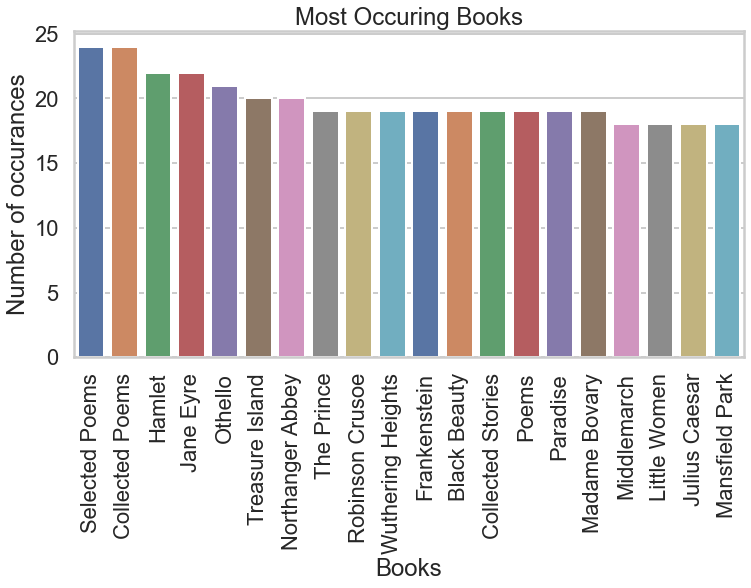

In [5]:
#Taking the first 20:

sns.set_context('poster')
plt.figure(figsize = (12,6))
Reccuring_names = sns.barplot(books['BookTitle'].value_counts().head(20).index,
                            books['BookTitle'].value_counts().head(20).values, palette="deep")
Reccuring_names.set_xticklabels(Reccuring_names.get_xticklabels(), rotation=90)
plt.title("Most Occuring Books")
Reccuring_names.set_xlabel('Books')
Reccuring_names.set_ylabel('Number of occurances')
plt.show()

We can see that "Hamlet", "Jane Eyre", "Othello" and Other Classics have the most number of occurrances with the same name in the data.


These books have come up in this database over and over again, with various publication editions. From the list, we can see that most of the books from the given chart are either old, steadfast classics or books which are usually assigned to schools. Seems like some books do age well, and these have just stood against the flow of time.


### 1.2. Which are the top 10 most rated books? Which book is the most popular?

<AxesSubplot:xlabel='TotalRatingCount', ylabel='BookTitle'>

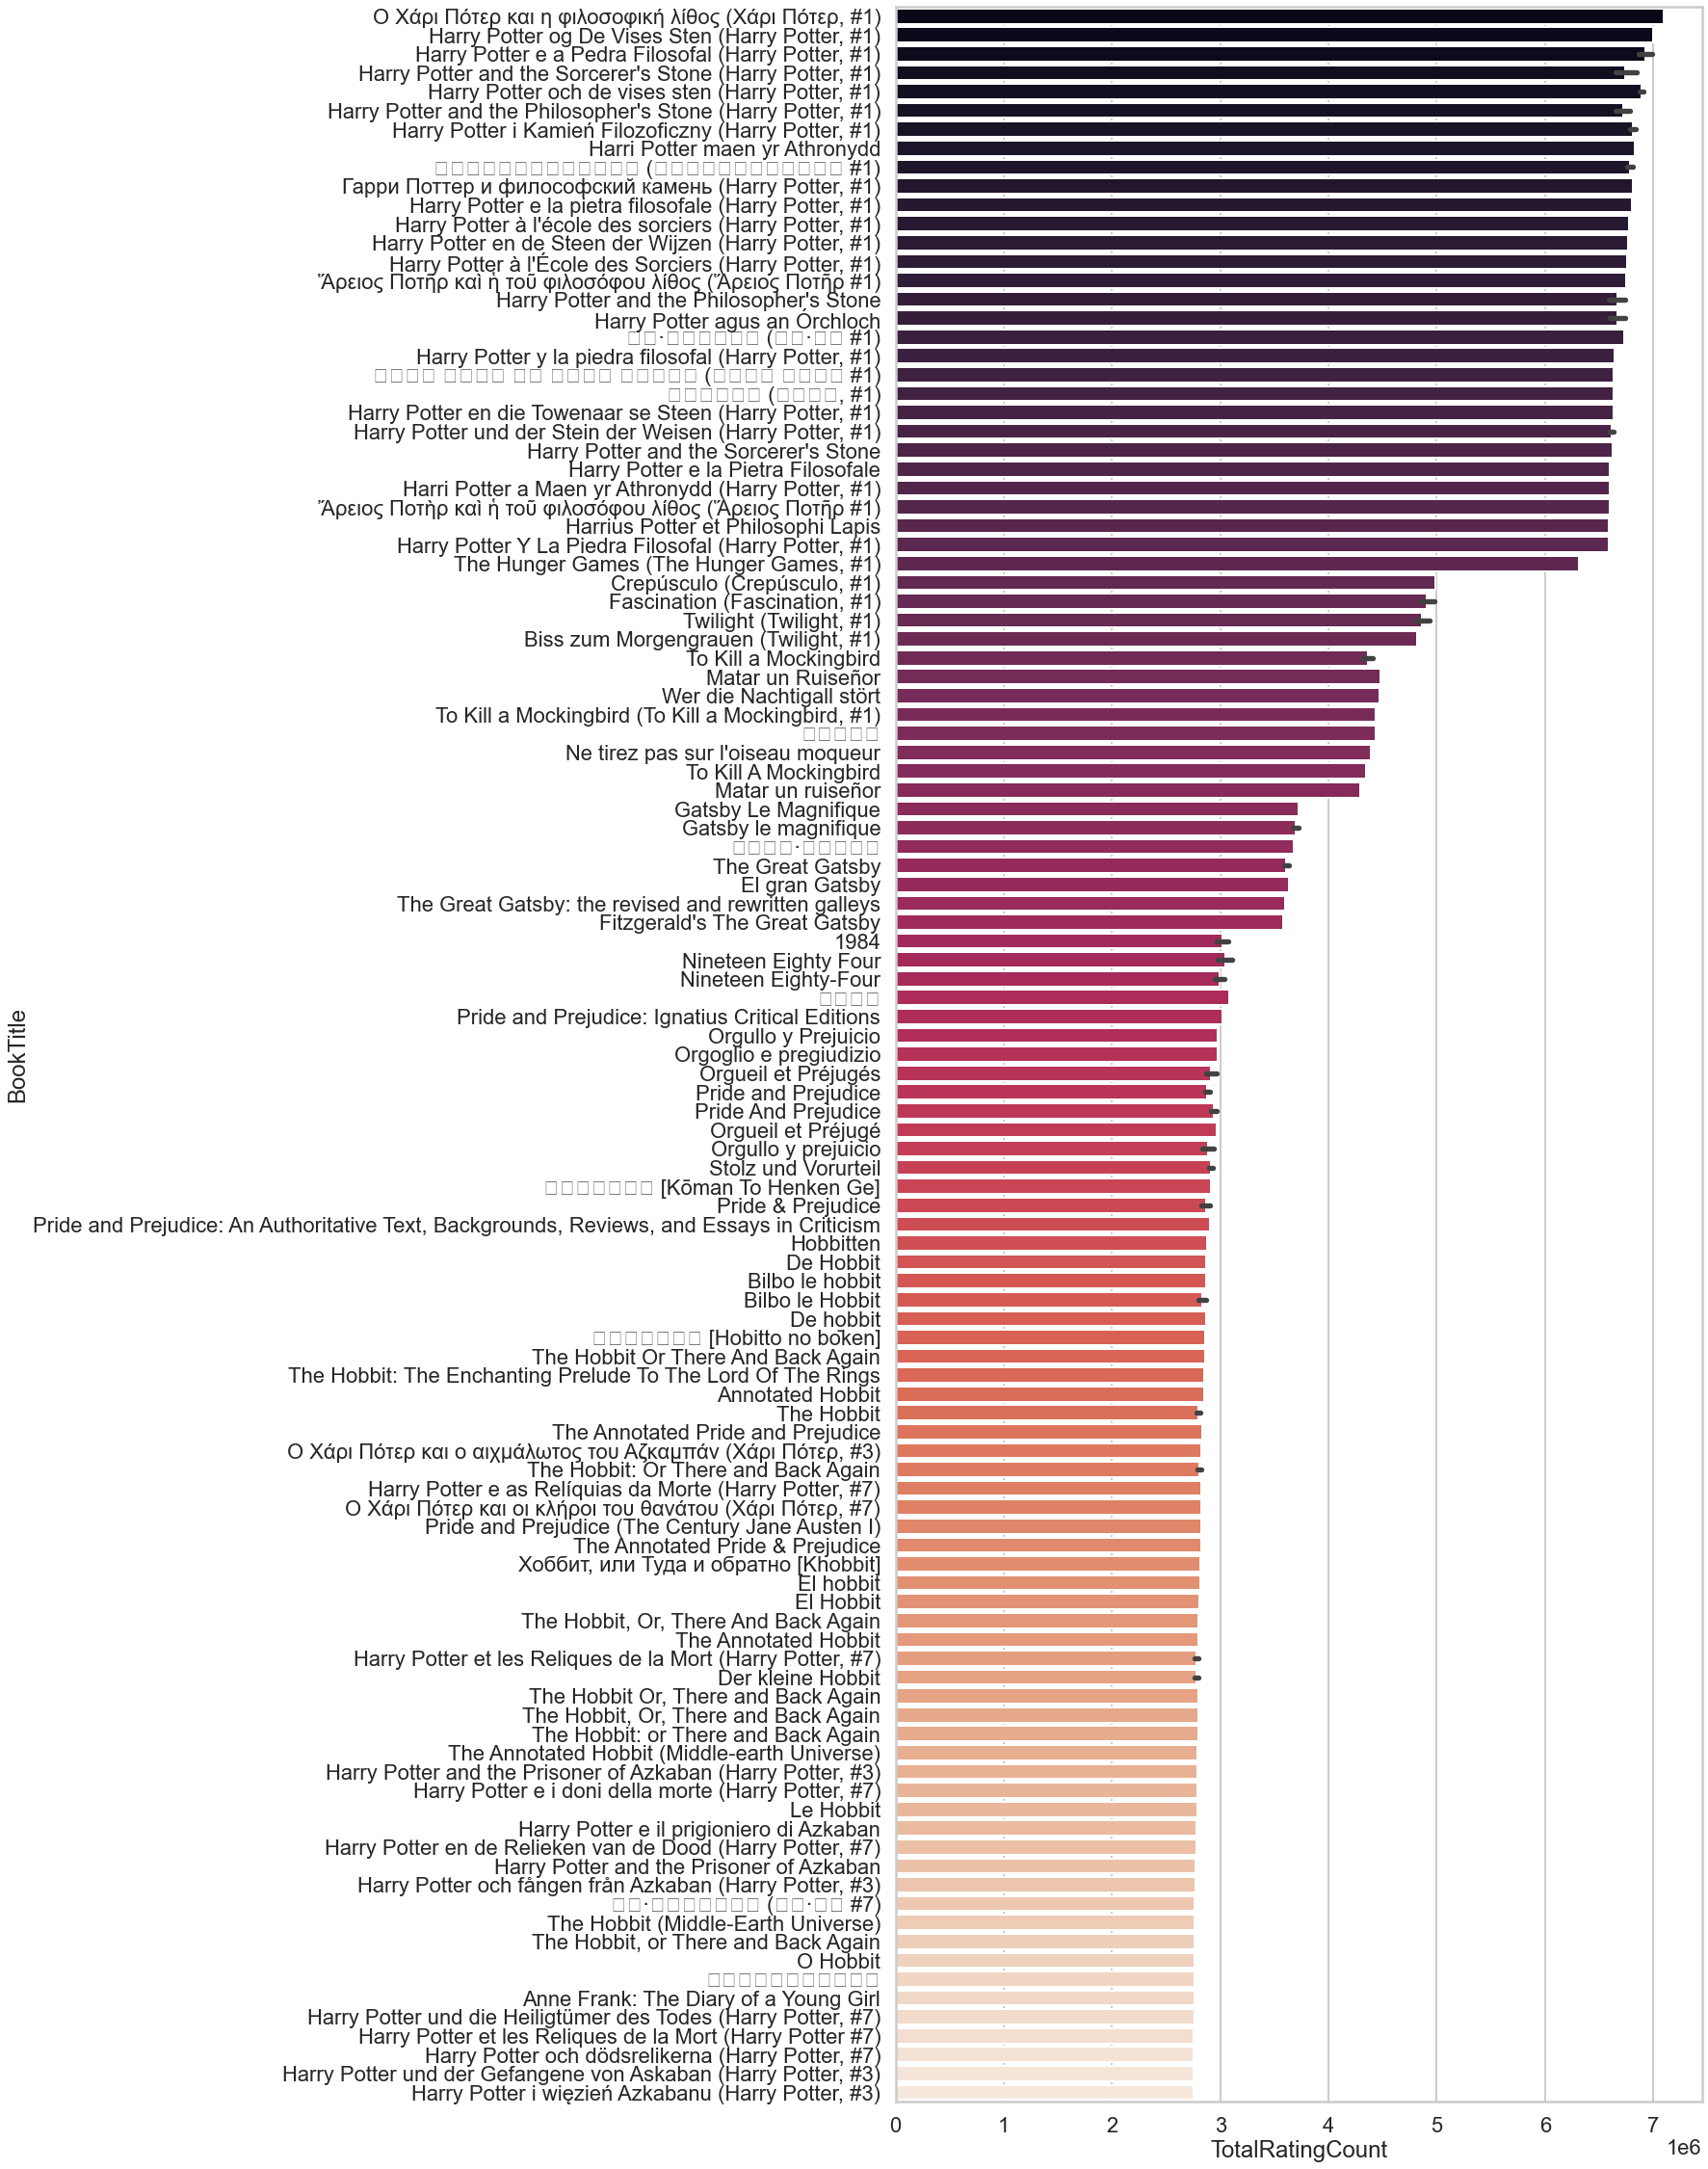

In [6]:
most_rated = books.sort_values('TotalRatingCount', ascending = False).head(200).set_index('BookTitle')
plt.figure(figsize=(15,40))
sns.barplot(most_rated['TotalRatingCount'], most_rated.index, palette='rocket')

- We can see that even though we plotted 200 most rated books, they are just 10 books in total. These few books as well as their translations or special editions are bestsellers too 
- We can certainly say that #1 book of Harry Potter series viz. "Harry Potter and Philosophers Stone" is most rated book with over 25 translations in top 200 and each with 6 Millions+ Total ratings Count.


- This is the rating of the top 10 Books: 
    - Harry Potter #1 + translations each over 6M first 29 places
    - Twillight #1 + translations 
    - To Kill a Mockingbird + translations 
    - The Great Gatsby + translations
    - Pride and Prejudice + translations
    - The Hobbit + translations
    - Harry Potter #7 + translations
    - Harry Potter #3
    - Hunger Games #1
    - Anne Frank: Diary of a Young Girl

- Almost every book mentioned here has almost 10 different translations and each is bestseller

In [7]:
# Let's check the book with biggest number of rates (total)
books[books['TotalRatingCount'] == books['TotalRatingCount'].max()]

,BookID,BookTitle,Authors,AverageRating,1StarRatingCount,2StarRatingCount,3StarRatingCount,4StarRatingCount,5StarRatingCount,TotalRatingCount,PageCount,Publisher,PublishYear
1607049,4593339,Ο Χάρι Πότερ και η φιλοσοφική λίθος (Χάρι Πότε...,J.K. Rowling,4.47,119534,140565,603633,1621963,4608992,7094687,360,Εκδόσεις Ψυχογιός,1998-01-01


- Well this is Greek Translation of "Harry Potter #1" by JK Rowling
- This is by Total Rating Count, but we may have to see by 5 star rating count

In [8]:
# And let's check the book with biggest number of 5-star rates
books[books['5StarRatingCount'] == books['5StarRatingCount'].max()]

,BookID,BookTitle,Authors,AverageRating,1StarRatingCount,2StarRatingCount,3StarRatingCount,4StarRatingCount,5StarRatingCount,TotalRatingCount,PageCount,Publisher,PublishYear
1607049,4593339,Ο Χάρι Πότερ και η φιλοσοφική λίθος (Χάρι Πότε...,J.K. Rowling,4.47,119534,140565,603633,1621963,4608992,7094687,360,Εκδόσεις Ψυχογιός,1998-01-01


- Again same book with almost 4.6 Million+ 5 star ratings stood at first place
- We will again search for books with average rating of 5.

In [9]:
books[books['AverageRating'] == 5]

,BookID,BookTitle,Authors,AverageRating,1StarRatingCount,2StarRatingCount,3StarRatingCount,4StarRatingCount,5StarRatingCount,TotalRatingCount,PageCount,Publisher,PublishYear
214,380,A Colorful Symphony: Full Score,Robert Xavier Rodríguez,5.0,0,0,0,0,1,1,68,"G. Schirmer, Inc.",1997-01-01
222,392,"Bullets, Badges, and Bullshit",Phil T. O'Brien,5.0,0,0,0,0,2,2,444,PublishAmerica,2006-01-01
257,438,"New York Trilogy: New York Underground, Trappe...",Paul Hallasy,5.0,0,0,0,0,2,2,156,iUniverse,2000-01-01
470,754,Guitar Picture Chords in Color,Ed Lozano,5.0,0,0,0,0,3,3,56,Music Sales,2001-01-01
521,837,Angelfish,Dan Harrington,5.0,0,0,0,0,1,1,212,Lulu.com,2006-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683581,4846160,Straight And Devious Pathways From Childhood T...,Lee N. Robins,5.0,0,0,0,0,1,1,411,Cambridge University Press,1992-01-01
1683592,4846191,20th Century America,Time-Life Books,5.0,0,0,0,0,1,1,128,Time Life Medical,1999-01-01
1683609,4846241,Counterstrain Approaches In Osteopathic Manipu...,Harry Friedman,5.0,0,0,0,0,1,1,106,Sfimms Press,2000-01-01
1683630,4846302,Asking the Right Questions about Electronic Vo...,Richard Celeste,5.0,0,0,0,0,1,1,148,National Academies Press,2006-01-01


- We around 70k books with 5 ratings but they are rated very less times.
- We should check by filtering books with 5 rating and must have atleast 10000 ratings count.

In [10]:
books[(books['AverageRating'] == 5) & (books['TotalRatingCount'] > 1000)]

,BookID,BookTitle,Authors,AverageRating,1StarRatingCount,2StarRatingCount,3StarRatingCount,4StarRatingCount,5StarRatingCount,TotalRatingCount,PageCount,Publisher,PublishYear


- We get zero books so we will use slightly lesser rating of 4.75 as threshold

In [11]:
books[(books['AverageRating'] >4.75) & (books['TotalRatingCount'] > 10000)]

,BookID,BookTitle,Authors,AverageRating,1StarRatingCount,2StarRatingCount,3StarRatingCount,4StarRatingCount,5StarRatingCount,TotalRatingCount,PageCount,Publisher,PublishYear
6,8,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...",J.K. Rowling,4.78,402,283,1201,4650,37432,43968,2690,Scholastic,2004-01-01
13604,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,131,167,770,3491,29520,34079,1456,Andrews McMeel Publishing,2005-01-01
13606,24814,"It's a Magical World (Calvin and Hobbes, #11)",Bill Watterson,4.76,43,63,897,3958,20468,25429,176,Andrews McMeel Publishing,1996-01-01
51924,95602,Mark of the Lion Trilogy,Francine Rivers,4.77,37,74,347,1526,9168,11152,1468,Tyndale House,1998-01-01
137571,257939,"Harry Potter Boxed Set (Harry Potter, #1-5)",J.K. Rowling,4.78,410,285,1214,4719,38097,44725,2000,Scholastic Inc.,2003-01-01
607594,1294255,Calvin & Hobbes: It's a Magical World,Bill Watterson,4.76,45,63,904,3983,20618,25613,165,Andrews McMeel Publishing,1996-01-01
882064,2104624,Calvin And Hobbes: It's a Magical World,Bill Watterson,4.76,46,64,907,3988,20720,25725,165,Routledge,1996-01-01


- "Harry Potter Book Series", "Calvin and Hobbes comics series" and "Mark of Lion Triology" are the names we come up with.
- We can say that "Harry Potter Book Series" heavily dominates the race of most popular books in all aspects.

### 1.3. Which are the authors with most books?

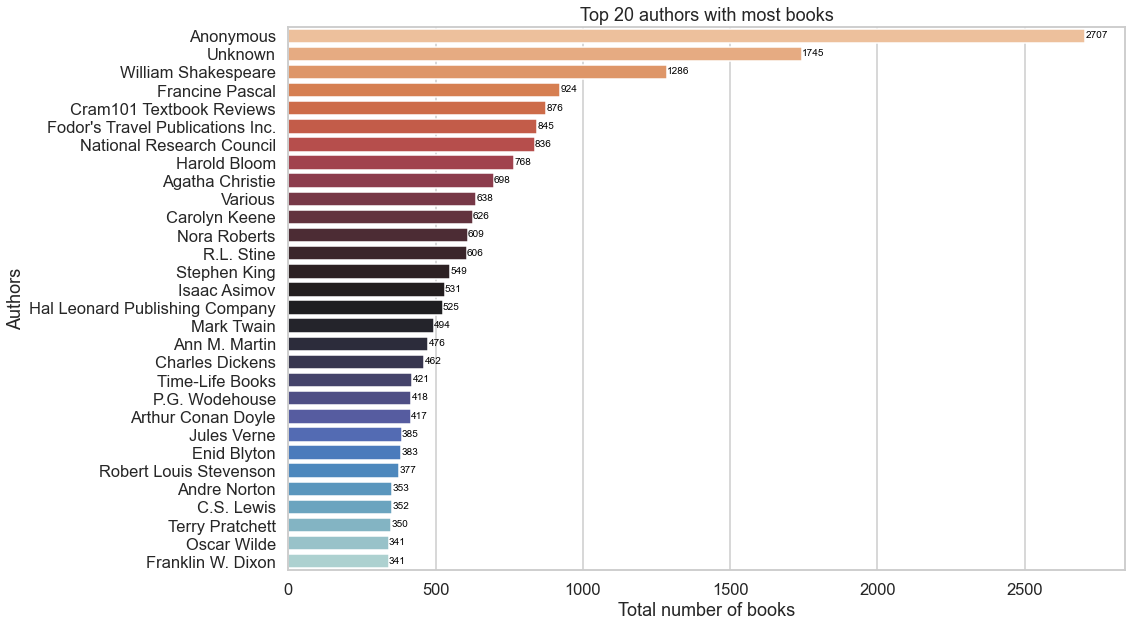

In [12]:
sns.set_context('talk')
most_books = books.groupby('Authors')['BookTitle'].count().reset_index().sort_values('BookTitle', ascending=False).head(30).set_index('Authors')
plt.figure(figsize=(15,10))
ax = sns.barplot(most_books['BookTitle'], most_books.index, palette='icefire_r')
ax.set_title("Top 20 authors with most books")
ax.set_xlabel("Total number of books")
for i in ax.patches:
    ax.text(i.get_width()+.3, i.get_y()+0.5, str(round(i.get_width())), fontsize = 10, color = 'k')
    

 - These are the top 20 Authores by the number of books they Authored:
    - William Shakespeare
    - Francine Pascal
    - Harold Bloom
    - Agatha Christie
    - Carolyn Keene
    - Nora Roberts
    - RL Stine
    - Stephen King
    - Issac Asimov
    - Mark Twain
    - Ann M Martin
    - Charles Dickens
    - PG Woodhouse
    - Arthur Conan Doyle
    - Jules Verne
    - Enid Blyton
    - Robert Louise Stevenson 
    - Andre Norton
    - CS Lewis
    - Oscar Wilde

- William Shakespeare is worthy authored who wrote many plays etc
- To be honest, we can conclude that these authors have little impossible number of books written but this exaggerated number comes from fact that the translated and/or edited version of these were credited to them.
- We still see the names of many famous and popular authors in this top 20 authors with most books list.
- From little research I did on GoodReads Website, I came to know more about "Anonymous" and "Unknown" authors.
- Books can be attributed to "Anonymous" for several reasons:
    * They are officially published under that name
    * They are traditional stories not attributed to a specific author
    * They are religious texts not generally attributed to a specific author
- Books whose authorship is merely uncertain should be attributed to "Unknown". Meanwhile, the Unknown profile says: Books can be attributed to "Unknown" when the author is not known and cannot be discovered. If at all possible, list at least one actual author or editor for a book.
- Books whose authorship is purposefully withheld should be attributed instead to "Anonymous". 

### 1.4. Which are the top 10 highly rated authors? Which author is the most popular?

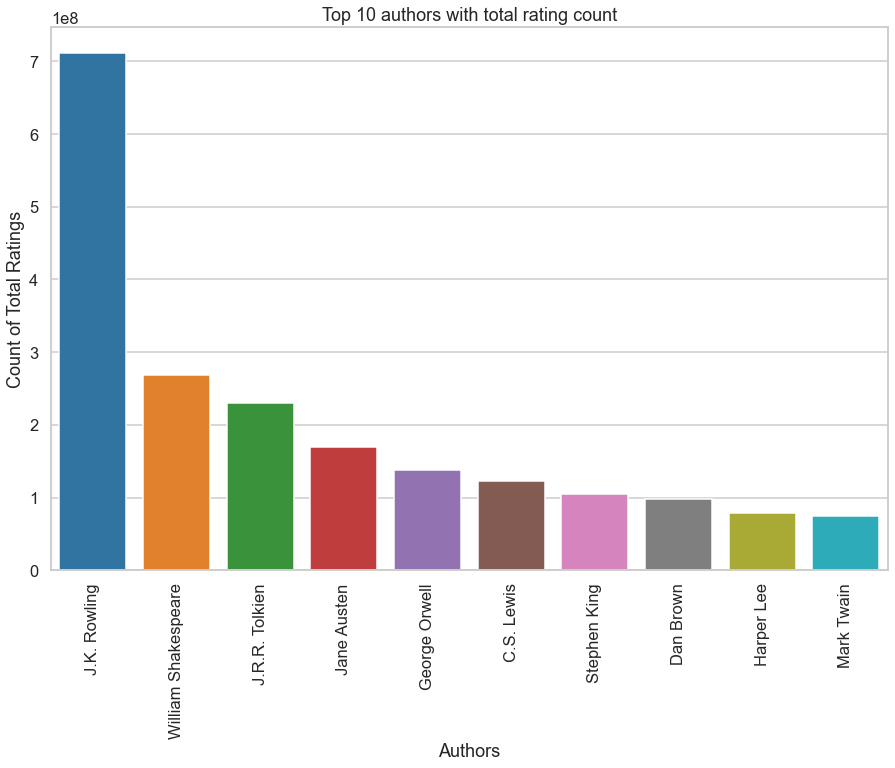

In [34]:
# Let's check authors with biggest number of rates (total number for all books)
totalratingcount= books.groupby('Authors')['TotalRatingCount'].sum().sort_values(ascending = False).head(10)
plt.figure(figsize=(15,10))
plottrc = sns.barplot(x = totalratingcount.index, y = totalratingcount.values)
plottrc.set_xticklabels(plottrc.get_xticklabels(), rotation=90)
plottrc.set_title("Top 10 authors with total rating count")
plottrc.set_ylabel("Count of Total Ratings")
plt.show()

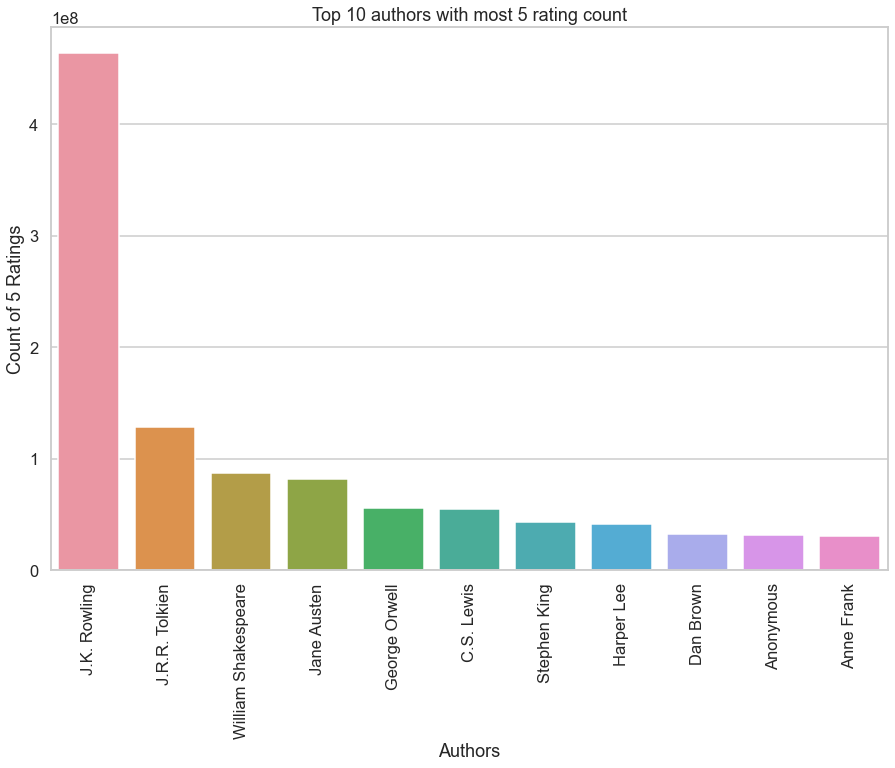

In [35]:
# Let's check authors with biggest number of 5 ratings
totalratingcount= books.groupby('Authors')['5StarRatingCount'].sum().sort_values(ascending = False).head(11)
plt.figure(figsize=(15,10))
plottrc = sns.barplot(x = totalratingcount.index, y = totalratingcount.values)
plottrc.set_xticklabels(plottrc.get_xticklabels(), rotation=90)
plottrc.set_title("Top 10 authors with most 5 rating count")
plottrc.set_ylabel("Count of 5 Ratings")
plt.show()

- Almost same list is produced with both methods. 
- By seeing names of these maestroes we can say that our list is quite right.
- JK Rowling is undoubted number one in both lists. W. Shakespeare has more overall ratings but JRR Tolkien has more 5 ratings. These 5 writers are top 3 authors.
- add more later....

### 1.5. Getting overall performance for an author over time

In [36]:
books.groupby('Authors')['5StarRatingCount'].sum().sort_values(ascending = False).head(11)

Authors
J.K. Rowling           464135217
J.R.R. Tolkien         128218617
William Shakespeare     86869919
Jane Austen             82203032
George Orwell           55456265
C.S. Lewis              54972366
Stephen King            42867756
Harper Lee              41340002
Dan Brown               32271835
Anonymous               31585484
Anne Frank              30630969
Name: 5StarRatingCount, dtype: int64

In [37]:
top_10_authors = ['J.K. Rowling','J.R.R. Tolkien','William Shakespeare','Jane Austen','George Orwell','C.S. Lewis',
           'Stephen King','Harper Lee','Dan Brown','Anne Frank']

- what are these authors explain.....
- We selected 10 authors which got highest number 5 Star Ratings as top 10 authors
- We are then going to check how many publications are done by these authors (either origional book or republication or translation credit)
- If book number is more than 20 we will check performance of these authors over the years.

In [40]:
for author in top_10_authors:
    print(f'{author} : {books.Authors.value_counts()[author]}')

J.K. Rowling : 235
J.R.R. Tolkien : 297
William Shakespeare : 1286
Jane Austen : 272
George Orwell : 141
C.S. Lewis : 352
Stephen King : 549
Harper Lee : 18
Dan Brown : 63
Anne Frank : 32


- Many authors have multiple publications.
- Anne Frank has only two books but they were translated or republished with different publisher. These counts will help us to establish authors performance clearly.
- We are trying out how the ratings of authors changes as their new publication comes out.

========== J.K. Rowling



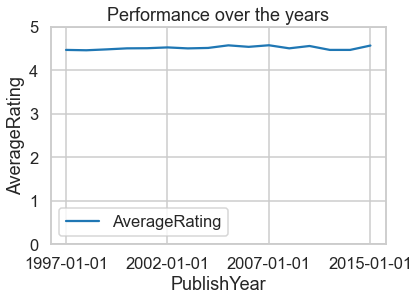

========== J.R.R. Tolkien



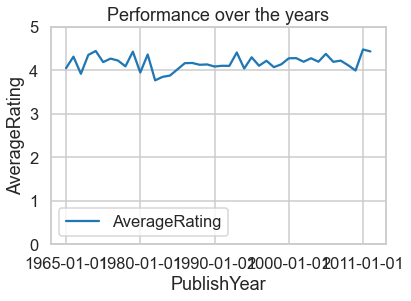

========== William Shakespeare



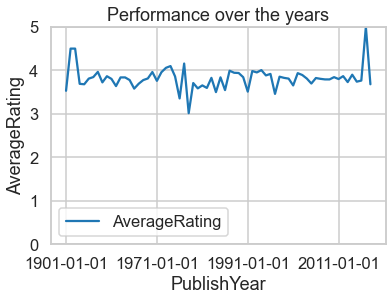

========== Jane Austen



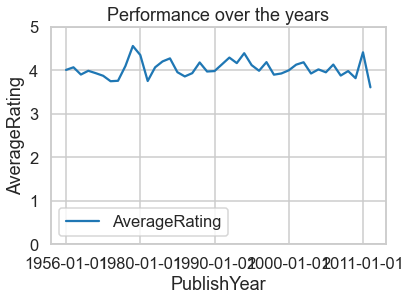

========== George Orwell



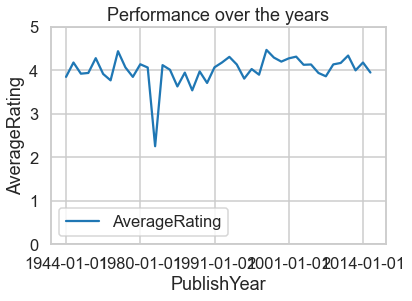

========== C.S. Lewis



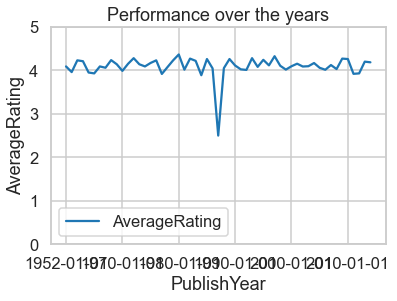

========== Stephen King



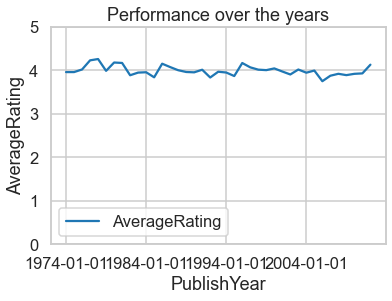

========== Harper Lee



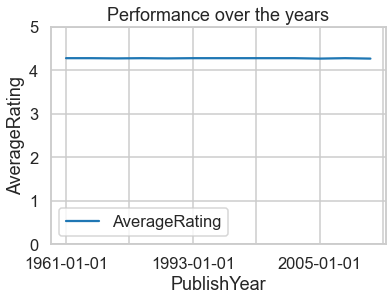

========== Dan Brown



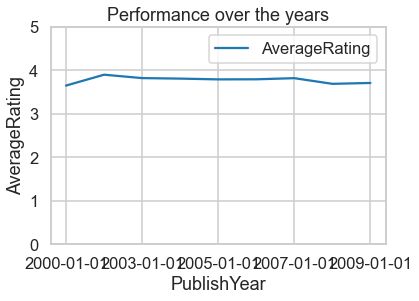

========== Anne Frank



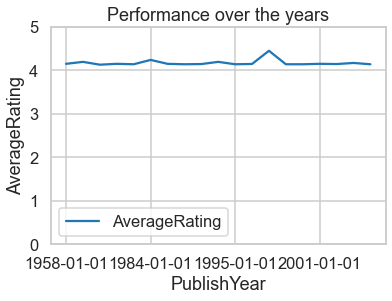

In [61]:
for author in top_10_authors:
    print('='*10 + '\033[1m' + ' '+ author)
    print('\033[0m')
    author_data = books[books['Authors']==author]
    author_data.groupby(by="PublishYear")["AverageRating"].mean().plot(
        legend=True, title="Performance over the years", ylabel= 'AverageRating', ylim= (0,5))
    plt.show()

- We can say that J.K. Rowling has most stable performance over the years and her average rating for each publication remains around 4.5 ...
- ...

### 1.6. What is the rating distribution for the books?

In [67]:
def segregation(data):
    values = []
    for val in data.AverageRating:
        if val>=0 and val<=1:
            values.append("Between 0 and 1")
        elif val>1 and val<=2:
            values.append("Between 1 and 2")
        elif val>2 and val<=3:
            values.append("Between 2 and 3")
        elif val>3 and val<=4:
            values.append("Between 3 and 4")
        elif val>4 and val<=5:
            values.append("Between 4 and 5")
        else:
            values.append("NaN")
    print(len(values))
    return values

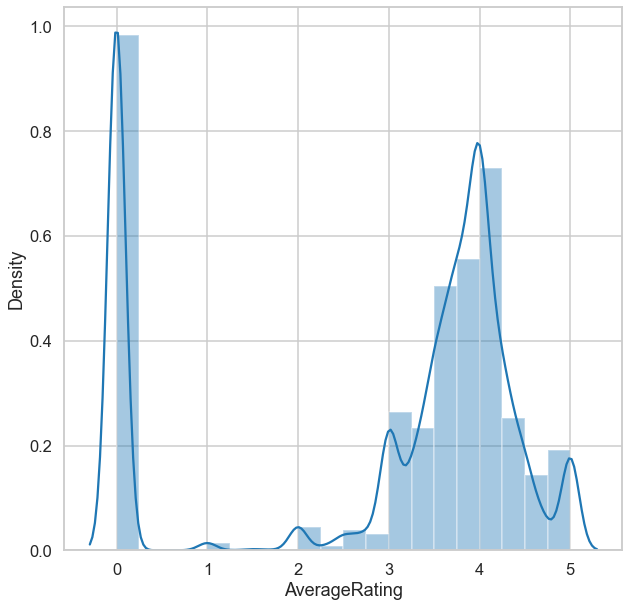

In [70]:
plt.figure(figsize=(10,10))
rating= books.AverageRating.astype(float)
sns.distplot(rating, bins=20)
plt.show()

- ......
- ????? From the given plot, we can infer that: Majority of the ratings lie near 3.7-4.3, approximately. Books having scores near 5 are extremely rare



1683667


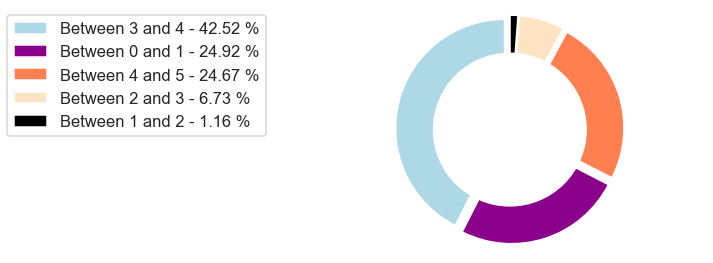

In [72]:
books['Ratings_Dist'] = segregation(books)
ratings_pie = books['Ratings_Dist'].value_counts().reset_index()
labels = ratings_pie['index']
colors = ['lightblue','darkmagenta','coral','bisque', 'black']
percent = 100.*ratings_pie['Ratings_Dist']/ratings_pie['Ratings_Dist'].sum()
fig, ax1 = plt.subplots()
ax1.pie(ratings_pie['Ratings_Dist'],colors = colors, 
        pctdistance=0.85, startangle=90, explode=(0.05, 0.05, 0.05, 0.05, 0.05))
#Draw a circle now:
centre_circle = plt.Circle((0,0), 0.70, fc ='white')
fig1 = plt.gcf()
fig1.gca().add_artist(centre_circle)
#Equal Aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')
plt.tight_layout()
labels = ['{0} - {1:1.2f} %'.format(i,j) for i,j in zip(labels, percent)]
plt.legend( labels, loc = 'best',bbox_to_anchor=(-0.1, 1.),)
plt.show()

- Surprisingly, it can be seen that the ratings between 0 and 1 are much more numerous in number, leading to a conclusion that if a person does read a book and end up hating it, it'll still get a minimum of around 2 stars, just for the effort they put up for reading the book.

- The kurtosis of the graph just seems to land between 3 and 4, signifying that for the effort it took to read, and the thrilling, unputdownable nature of the book, the majority of the ratings lie between 3 and 4.


### 1.7. Is there a relationship between number of pages and ratings?

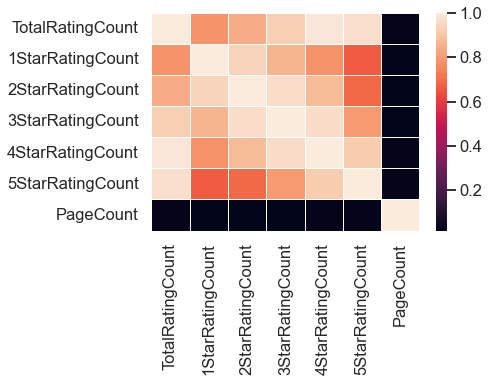

In [66]:
data = books[['TotalRatingCount', '1StarRatingCount', '2StarRatingCount', '3StarRatingCount', '4StarRatingCount', 
       '5StarRatingCount', 'PageCount']].corr()
sns.heatmap(data, linewidth=.5)
plt.show()

- Seems, that number of reviews doesn't depend on number of pages and it's good news for authors. ........

<Figure size 1080x720 with 0 Axes>

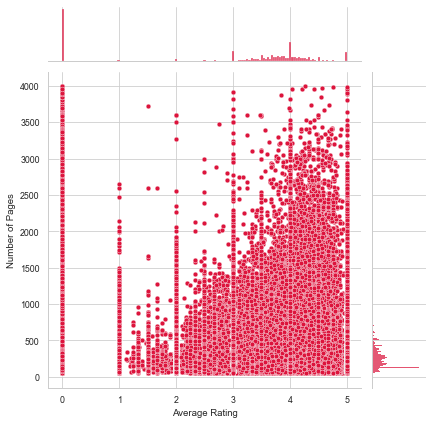

In [73]:
plt.figure(figsize=(15,10))
sns.set_context('paper')
ax = sns.jointplot(x="AverageRating", y="PageCount", data = books, color = 'crimson')
ax.set_axis_labels("Average Rating", "Number of Pages")
plt.show()


???????????
Analysis: This plot doesn't give that much of an accurate inference due to the massive presence of outliers for books above 1000 pages, for the maximum density is between 0-1000 pages.

Based on that logic, let's explore the scenario in that range:
???????????


In [75]:
trial = books[~(books['PageCount']>1000)]

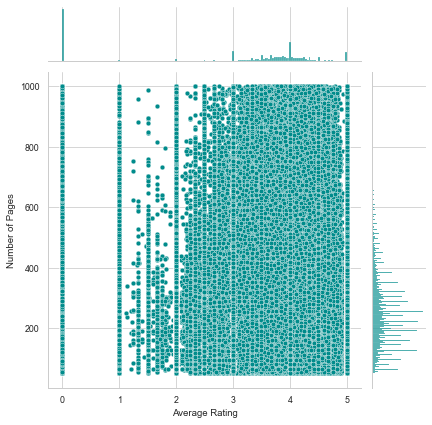

In [76]:
ax = sns.jointplot(x="AverageRating", y="PageCount", data = trial, color = 'darkcyan')
ax.set_axis_labels("Average Rating", "Number of Pages")
plt.show()

????


Analysis: From the given plot, we can infer that the highest ratings ever given, usually are for books with the page range of 150-350. It could lead to the fact that most of the people seem to prefer books with a moderate amount of pages, and that thicker books seems to scare people away.

??????

### 1.8. Is there a relationship between ratings and ratings count?

In [95]:
sns.set_context('paper')
ax = sns.jointplot(x="AverageRating", y="TotalRatingCount", data = books, color = 'blueviolet')
ax.set_axis_labels("Average Rating", "Ratings Count")
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x0000026C8F982EE0> (for post_execute):


KeyboardInterrupt: 

??????


There seem to be some outliers present in this. For a better outlook, let's consider the count around 2000000 ratings

?????????

In [ ]:
trial = books[~(books.ratings_count>2000000)]

In [ ]:
sns.set_context('paper')
ax = sns.jointplot(x="AverageRating", y="TotalRatingCount", data = trial, color = 'brown')
ax.set_axis_labels("Average Rating", "Ratings Count")
plt.show()

????????


From the graph, we can see that there can be a potential relationship between the average rating and ratings count. As the number of ratings increase, the rating for the book seems to taper towards 4. The average rating seems to become sparse while the number keeps on decreasing.

???????

### 1.9. Is there tendency to reduce number of pages in nowaday books?

In [79]:
books.groupby(['PublishYear'])['PageCount'].mean().tail(10)

PublishYear
2011-01-01    290.919114
2012-01-01    297.348638
2013-01-01    290.375982
2014-01-01    261.132187
2015-01-01    243.050259
2016-01-01    257.408266
2017-01-01    287.827770
2018-01-01    281.078488
2019-01-01    303.195616
2020-01-01    417.288660
Name: PageCount, dtype: float64

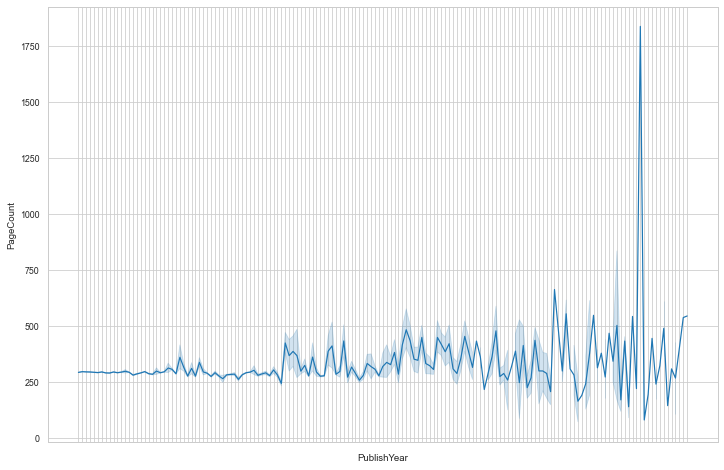

In [82]:
plt.figure(figsize = (12,8))
plotpyvspc = sns.lineplot(x = 'PublishYear', y = 'PageCount', data = books)
plotpyvspc.set_xticklabels(plotpyvspc.get_xticklabels(), rotation=90)
plt.show()

??????????? 

Analysis: This plot doesn't give that much of an accurate inference due to the massive presence of outliers for books above 1000 pages, for the maximum density is between 0-1000 pages.

Based on that logic, let's explore the scenario in that range: 

???????????


In [83]:
trial = books[~(books['PageCount']>1000)]

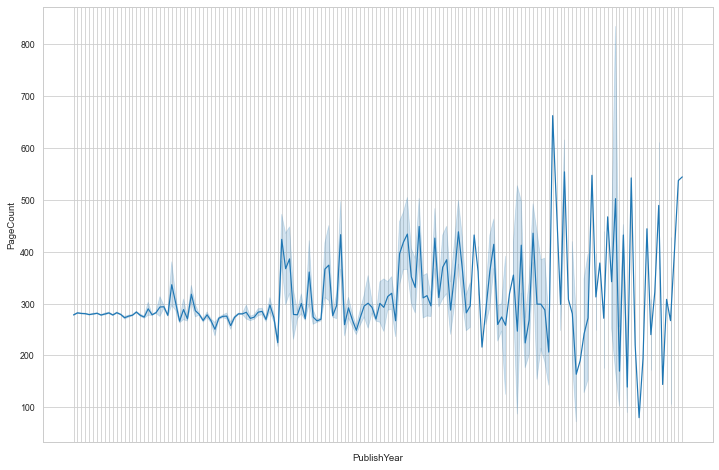

In [85]:
plt.figure(figsize = (12,8))
plotpyvspc = sns.lineplot(x = 'PublishYear', y = 'PageCount', data = trial)
plotpyvspc.set_xticklabels(plotpyvspc.get_xticklabels(), rotation=90)
plt.show()

???????????

Before 1900 number of pages was randomly distributed, then we can see that in 1900-1915 years books were mostly near 100-200 pages. After World War I and till mid of the century there is a distribution peak. During these years we got a lot of works of Lost Generation (Ernest Hemingway, F. Scott Fitzgerald, Erich Maria Remarque, John O'Hara, etc.), who wrote about wars, broken dreams, broken lives. I suppose, that their books were full of experiences, thoughts, frustration, which made book more volume.

After 1950 we see decaying curve and already nowadays number of pages is more or less stable and is near 250-300. It is hard for me to explain the fall to 200 pages near 2010-2015 years. Again - maybe there is lack of daya. Or maybe it is somehow related to active transition to electronic devices, but at the same time slow process of e-books supply (at least in my country). Everyday people have less and less time for reading, so authors dedicate themselves less for writing. However that is terrifying situation and already a lot of organisations noticed that, so last few years I can see more actions, that attract youth to read books, more apps that make reading easier, more e-books are now available.

Anyway - I'm not an expert in literature, so I can only make assumptions.

????????????

### 1.10. How many books gets published each year?

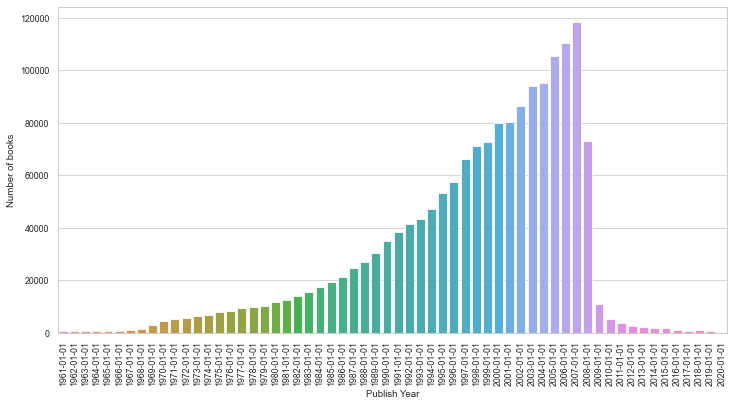

In [78]:
plt.figure(figsize = (12,6))
books_years = sns.barplot(y = books.groupby(['PublishYear'])['BookTitle'].count().tail(60), 
                          x = books.groupby(['PublishYear'])['BookTitle'].count().tail(60).index)
books_years.set_xticklabels(books_years.get_xticklabels(), rotation=90)
books_years.set_xlabel('Publish Year')
books_years.set_ylabel('Number of books')
plt.show()

?????????????

That's very interesting, that since 2008 such a big decrease has place! Maybe data is not full for that period?

????????

### 1.11. WordCloud of Book Titles


In [89]:
from wordcloud import WordCloud, STOPWORDS

In [92]:
# Setting stopwords for names
stopwords_names = set(STOPWORDS)
stopwords_names.update(['book', 'story', 'volume', 'essay', 'storie', 'vol', 'serie'])

# Creating words list for names
words_from_names = [word for rows in books['BookTitle'].str.lower().str.split() 
                    for word in rows if word not in stopwords_names]
names = " ".join(name for name in words_from_names)

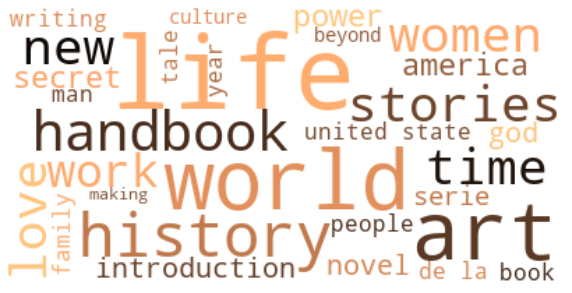

In [93]:
# Creating a cloud with words from names:
plt.figure(figsize = (10,6))
wordcloud = WordCloud(max_words=30, background_color="white", colormap = 'copper').generate(names)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

- ...........

================================================================================================

- ...........

- .............

================================================================================================